# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('drive/MyDrive/yulu_rental.csv')


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install matplotlib seaborn plotly==6.1.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 56.8 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [5]:
import matplotlib
import seaborn
import plotly

print("matplotlib version:", matplotlib.__version__)
print("seaborn version:", seaborn.__version__)
print("plotly version:", plotly.__version__)

matplotlib version: 3.10.0
seaborn version: 0.13.2
plotly version: 6.1.1


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
%matplotlib inline

In [8]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [9]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


В наборі 10886 рядків та 19 колонок. В одному рядку містяться дані за годину. Весь датасет містить дані з 01.01.2011 по 19.12.2012 рік, майже 2 роки спостережень. В датасеті наведена інформація про погодні умови, температуру повітря, чи є день святковим, чи робочим. Також ми бачимо кількість орендованих велосипедів та кількість зареєстрованих користувачів погодинно.

In [10]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


1. Згрупуйте дані про кількість орендованих велосипедів (count) поденно.

In [11]:

weekday_counts = df.groupby('weekday')['count'].sum()
weekday_counts

,count
weekday,
Friday,302504
Monday,295296
Saturday,311518
Sunday,285546
Thursday,306401
Tuesday,291985
Wednesday,292226


In [12]:
df['count'].sum()

np.int64(2085476)

2. Побудуйте з методом DataFrame.plot() лінійний графік поденної кількості орендованих велосипедів (count) за весь період в даних.

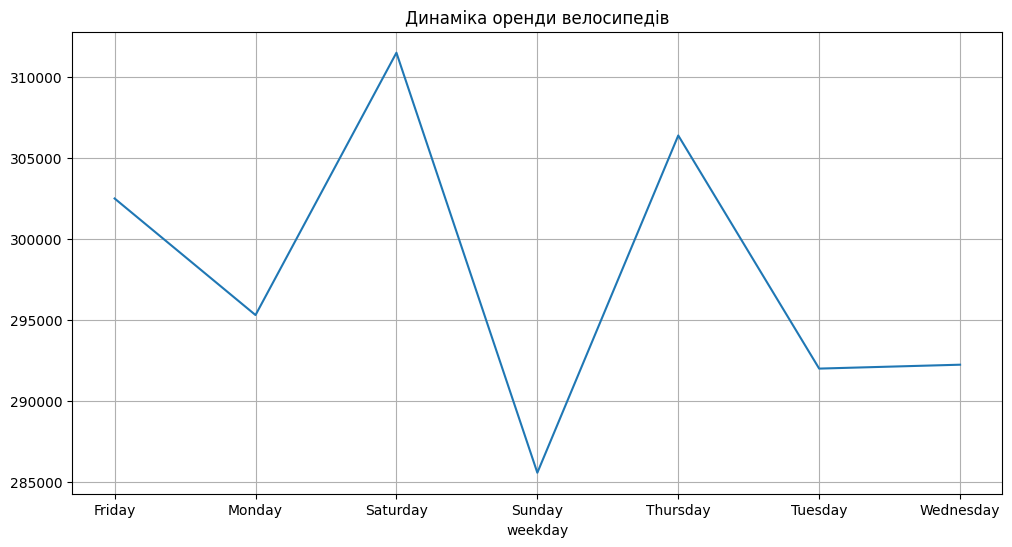

In [13]:
df.groupby('weekday')['count'].sum().plot(
    figsize=(12, 6), title='Динаміка оренди велосипедів',
    grid=True
    )
plt.show()

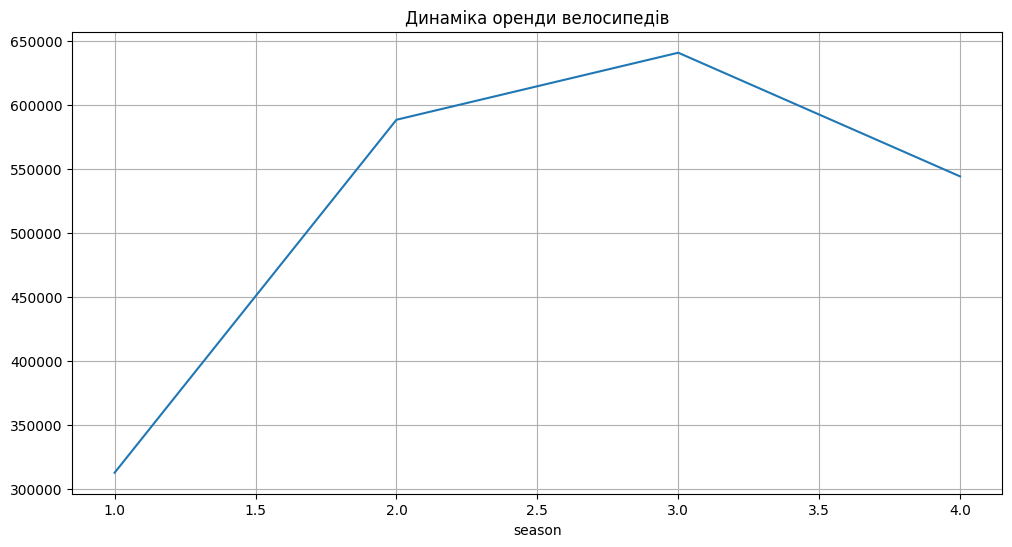

In [14]:
df.groupby('season')['count'].sum().plot(
    figsize=(12, 6), title='Динаміка оренди велосипедів',
    grid=True
    )
plt.show()

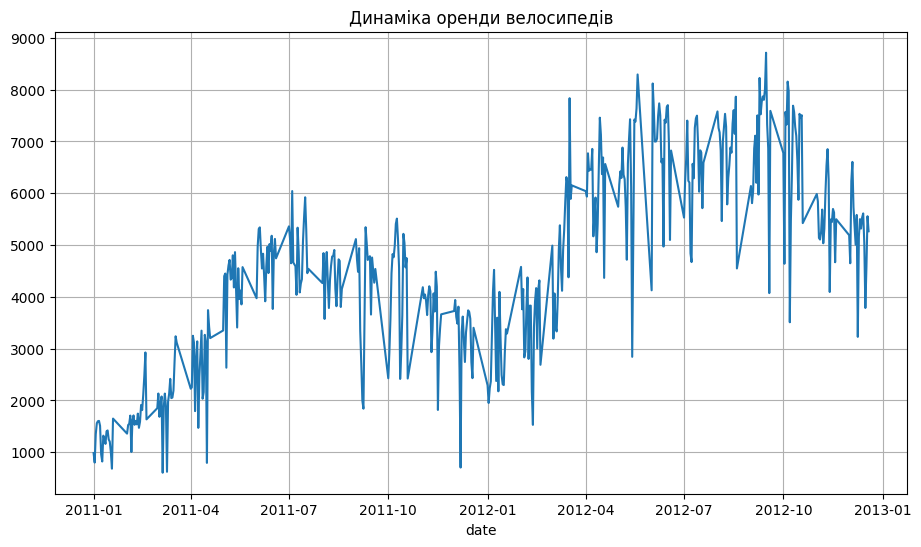

In [15]:
df.groupby('date')['count'].sum().plot(
    figsize=(11, 6), title='Динаміка оренди велосипедів',
    grid=True
    )
plt.show()

**Відповідь:** Графік має заломи, тому що оренда велосипедів залежить від погодних умов (weather, temp, humidity, windspeed), сезону (season, month), дня тижня, чи є день робочим або вихідним. З часом ми бачимо, що взагалі графік має висхідний тренд, це означає, що такі сервіси стають популярними, збільшується кількість користувачів. Так, сезонність тут дуже виражена. У теплі сезони: більше велосипедних поїздок, комфортні погодні умови, довший світловий день.
У зимові місяці: попит падає через холод і дощ. Частіше за все велосипеди орендують у четверг та суботу. Наприклад:
у будні зазвичай більше registered користувачів (дорога на роботу), погана погода може створити провал у графіку. Такі різкі локальні зміни й виглядають як «заломи».
Прибрати заломи можна змінивши поденну статистику на статистику по тижнях:
weekly = (
    df.groupby('week')['count']
      .sum()
)
Графік стане значно плавнішим.
Аномально низькі значення можливі за причин:
сильний дощ, сніг, буря, дуже низька температура,свята або локдауни/події.
Аномально високі значення можливі за причин:
теплі сонячні дні,вихідні з гарною погодою,масові міські заходи, туристичний сезон.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [16]:
avg_count_by_season = df.groupby(df.season)['count'].mean()

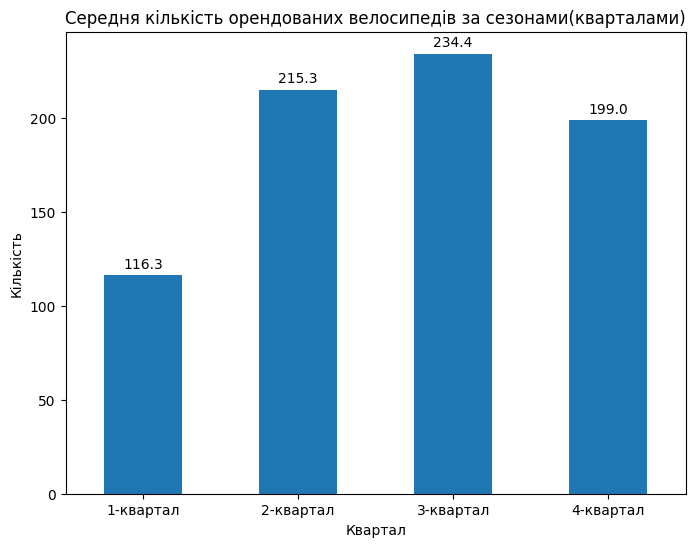

In [17]:
ax = avg_count_by_season.plot.bar(
    figsize=(8, 6),
    title='Середня кількість орендованих велосипедів за сезонами(кварталами)',
    xlabel='Квартал',
    ylabel='Кількість'
    )

# додавання підписів
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

# Налаштування підписів
ax.set_xticklabels(['1-квартал', '2-квартал', '3-квартал', '4-квартал'])
plt.xticks(rotation=0)

plt.show()


Найбільша середня кількість орендованих велосипедів у 3 кварталі (234,4). 3 квартал - це літні місяці, тобто сприятливі погодні умови для катання на велосипеді, тому і попит більший. Оренда велосипедів в 1 кварталі (116,3) у 2 рази менша, порівняно з 3 кварталом (234,4).

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [18]:
avg_count_by_month = df.groupby(df.month)['count'].mean()

In [19]:
avg_count_by_month

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


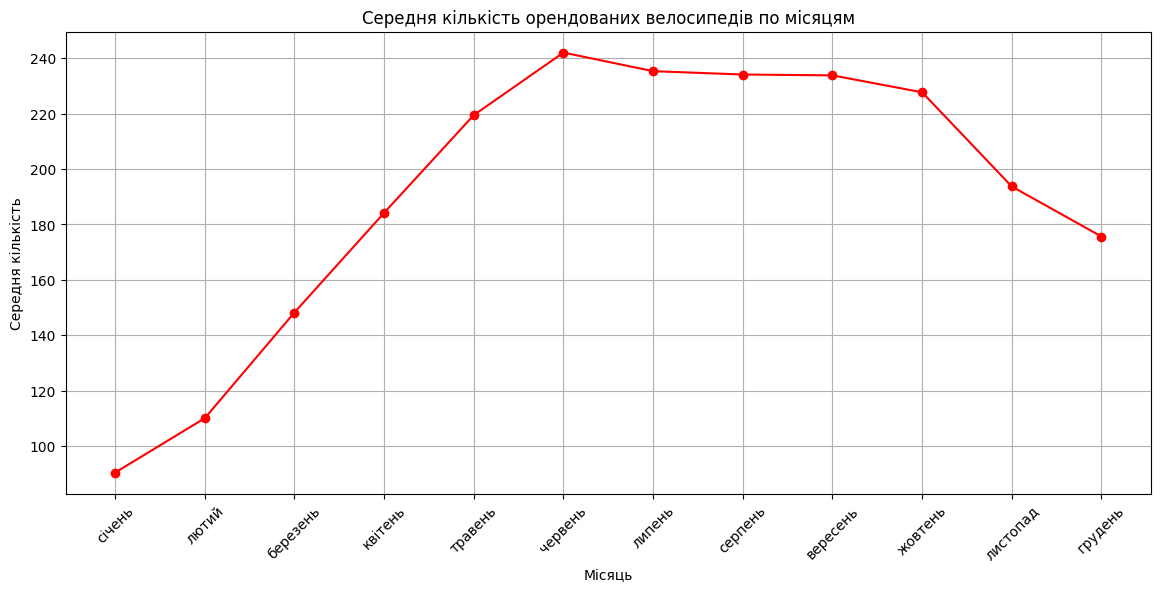

In [20]:
fig, ax = plt.subplots(figsize=(14,6))

avg_count_by_month.plot(
    kind='line',
    title='Середня кількість орендованих велосипедів по місяцям',
    marker='o',
    color='red',
    xlabel='Місяць',
    ylabel='Середня кількість',
    grid=True,
    ax=ax
)

months = [
    'січень', 'лютий', 'березень', 'квітень',
    'травень', 'червень', 'липень', 'серпень',
    'вересень', 'жовтень', 'листопад', 'грудень'
]

# ЯВНО задаємо всі 12 позицій
ax.set_xticks(range(1, 13))

# ЯВНО задаємо всі підписи
ax.set_xticklabels(months)

plt.xticks(rotation=45)

plt.show()

**Відповідь:** найбільший попит на оренду велосипедів спостерігаємо з травня по жовтень, найменший з грудня по березень. Ця закономірність збігається з результатами попередніх досліджень. Клімат суттєво впливає на попит на велосипеди. За несприятливих погодних умов кількість орендованих велосипедів зменшується.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [21]:
weather_distribution = df.groupby(df.weather)['count'].count()

In [22]:
weather_distribution

,count
weather,
1,7192
2,2834
3,859
4,1


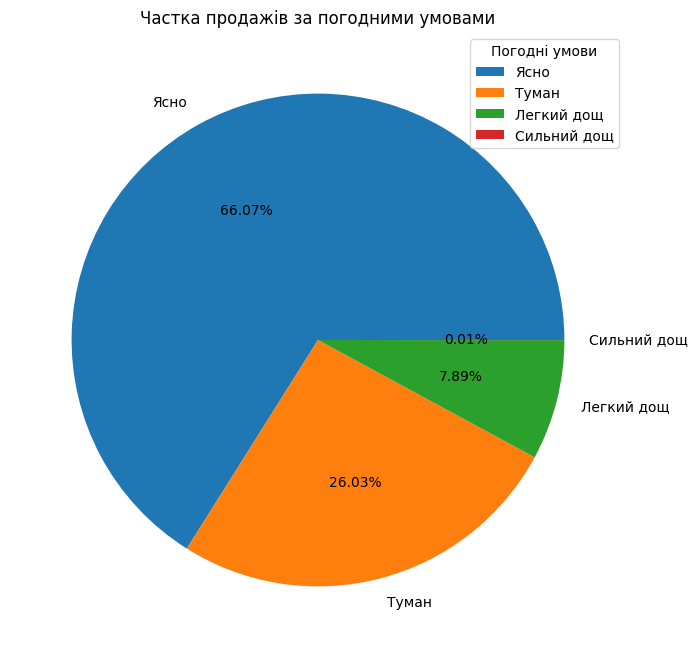

In [23]:
weather_distribution.plot.pie(
     figsize=(8, 8),
     autopct='%1.2f%%',
     labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
     title='Частка продажів за погодними умовами',
     #colormap='terrain',
     ylabel=''
)
plt.legend()
plt.legend(title='Погодні умови');

**Відповідь:** В цьому датасеті переважає ясна погода (66,07%). Дні з сильним дощем складають всього 0,01%. Тому виходячи з даних та графіка можна зробити висновок, що погодні умови безпосередньо впливають на попит на оренду велосипедів.

Очікуваний результат:

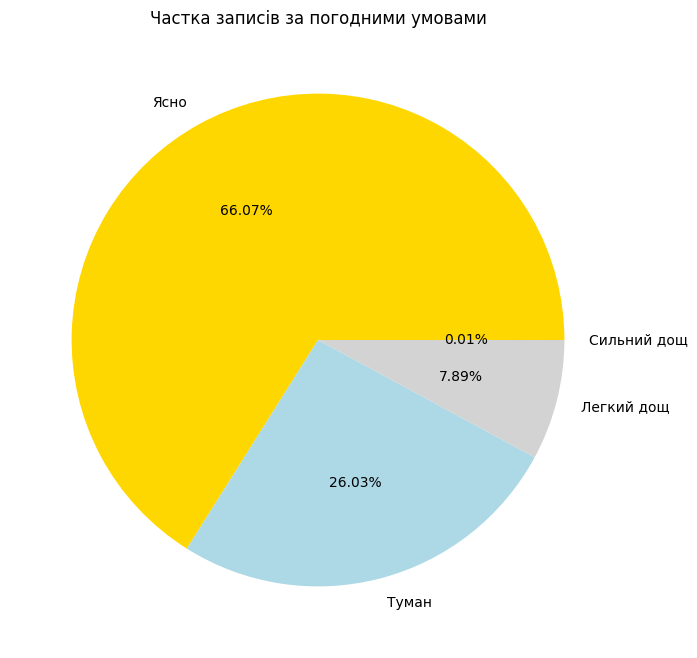

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

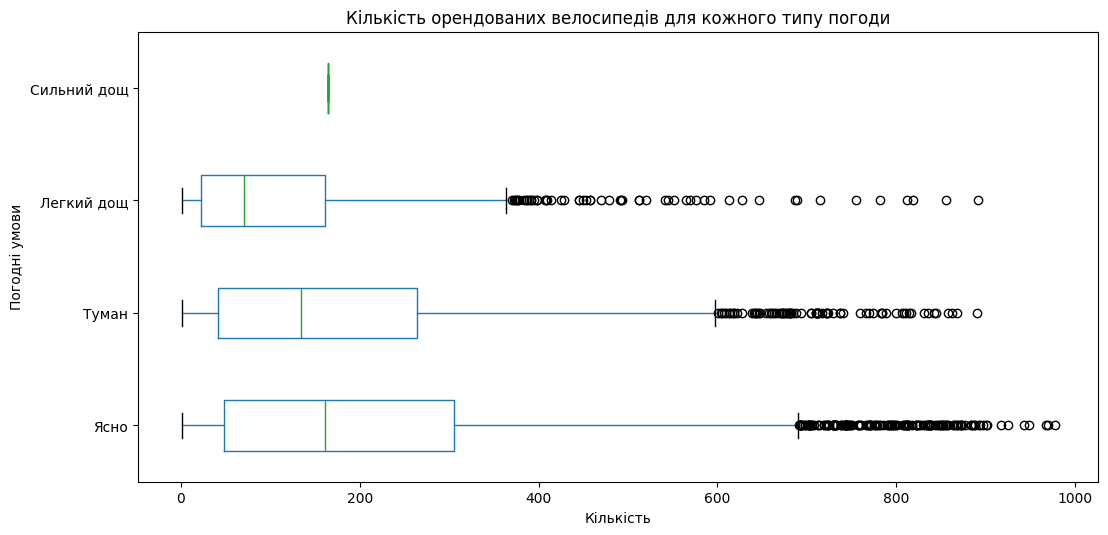

In [24]:
ax = df.boxplot(
     figsize=(12, 6),
     column='count',
     by='weather',
     grid = False,
     vert=False
)

weather_type = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

# ЯВНО задаємо всі 4 позиціi
ax.set_yticks(range(1, 5))

# ЯВНО задаємо всі підписи
ax.set_yticklabels(weather_type)

#plt.yticks(rotation=45)

plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.suptitle('')  # Видаляємо автоматичний заголовок
plt.ylabel('Погодні умови')
plt.xlabel('Кількість')
plt.show();

**Відповідь:** 1.Найбільший розкид спостерігається при ясній погоді. Це видно по широкому box, довгих «вусах»,великому діапазону значень. У хорошу погоду люди активно користуються велосипедами, але попит може змінюватися залежно від дня тижня, сезону,температури та ін.
2.Викиди присутні майже для всіх типів погоди, окрім сильного дощу.
Особливо їх багато при ясній погоді.Викиди - це дні з аномально високою кількістю оренд,або дуже низькою активністю. Можливі причини:свята, хороша погода, сильний дощ чи шторм та ін.
3.Найвище медіанне значення має ясна погода. Бо комфортні погодні умови
стимулюють поїздки, збільшують кількість casual-користувачів,
роблять велосипед популярнішим транспортом.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

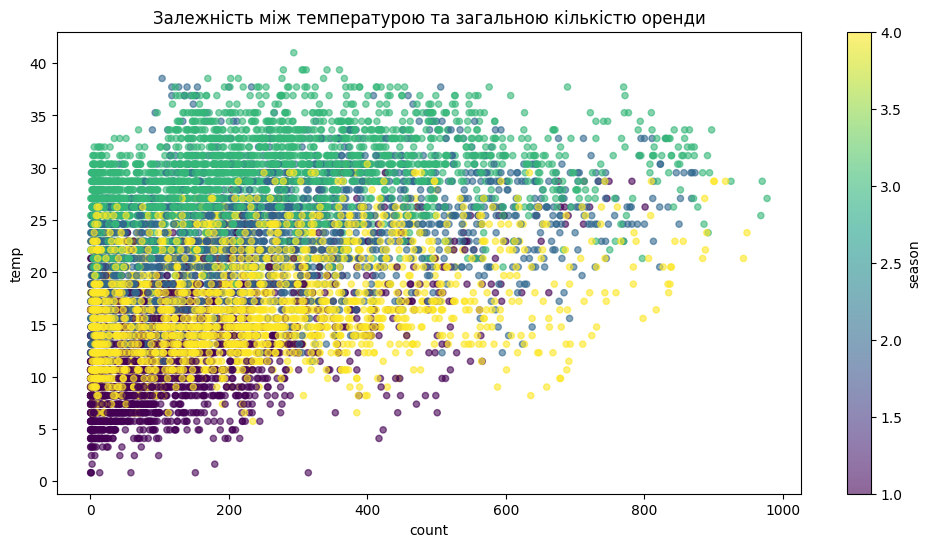

In [25]:
df.plot.scatter(
    figsize=(12, 6),
    x='count',
    y='temp',
    c='season',
    colormap='viridis',
    title='Залежність між температурою та загальною кількістю оренди',
    alpha=0.6
)
plt.show();

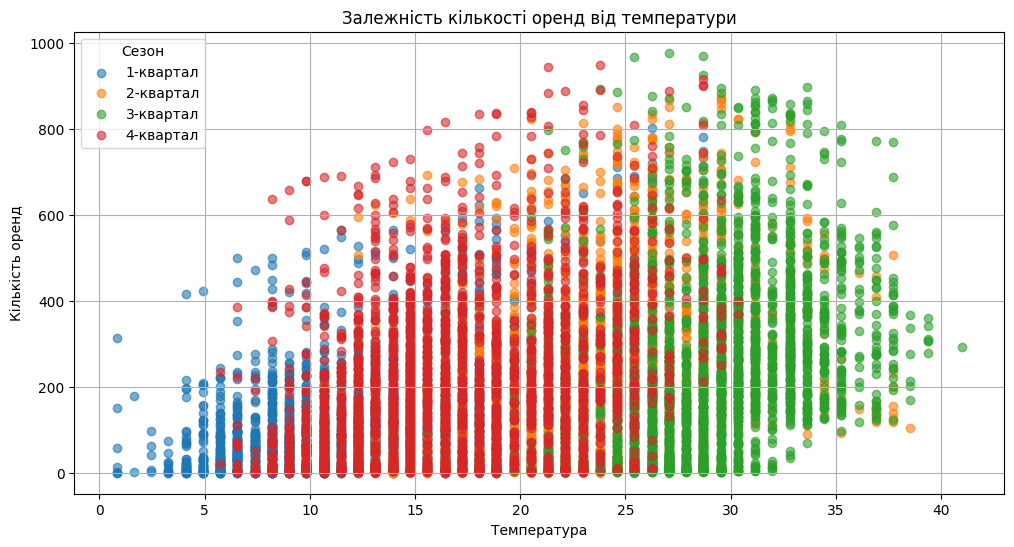

In [26]:
import matplotlib.pyplot as plt

# Назви сезонів
season_labels = {
    1: '1-квартал',
    2: '2-квартал',
    3: '3-квартал',
    4: '4-квартал'
}

# Додаємо назви сезонів
df['season_name'] = df['season'].map(season_labels)

# Кольори для сезонів
colors = {
    '1-квартал': 'green',
    '2-квартал': 'orange',
    '3-квартал': 'brown',
    '4-квартал': 'blue'
}

plt.figure(figsize=(12,6))

# scatter для кожного сезону
for season in df['season_name'].unique():
    subset = df[df['season_name'] == season]

    plt.scatter(
        subset['temp'],
        subset['count'],
        label=season,
        alpha=0.6
    )

plt.title('Залежність кількості оренд від температури')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')

plt.legend(title='Сезон')
plt.grid(True)

plt.show()

**Відповідь:** Так, між температурою та кількістю оренд спостерігається сильний зв’язок. Зі збільшенням температури кількість оренд загалом зростає, бо у теплі дні люди частіше користуються велосипедами; при низьких температурах оренд значно менше.
Зв’язок не ідеально лінійний, але чітко позитивний;
при дуже високих температурах зростання менше;
є помітний розкид точок через вплив інших факторів:погоди, вологості, вихідних,свят,часу доби. 2-й та 3-й квартал мають найбільшу кількість оренд. 1-й квартал концентрується в зоні низьких температур і нижчих значень count.
Для однакової температури різні сезони можуть мати різний попит через:
тривалість дня,опади, поведінкові особливості користувачів.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [36]:
avg_users_by_weekday=df.groupby(df.weekday)[['casual', 'registered']].mean()

In [37]:
avg_users_by_weekday

,casual,registered
weekday,,
Friday,31.001962,166.842381
Monday,29.843972,160.546744
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474
Thursday,24.007083,173.289118
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749


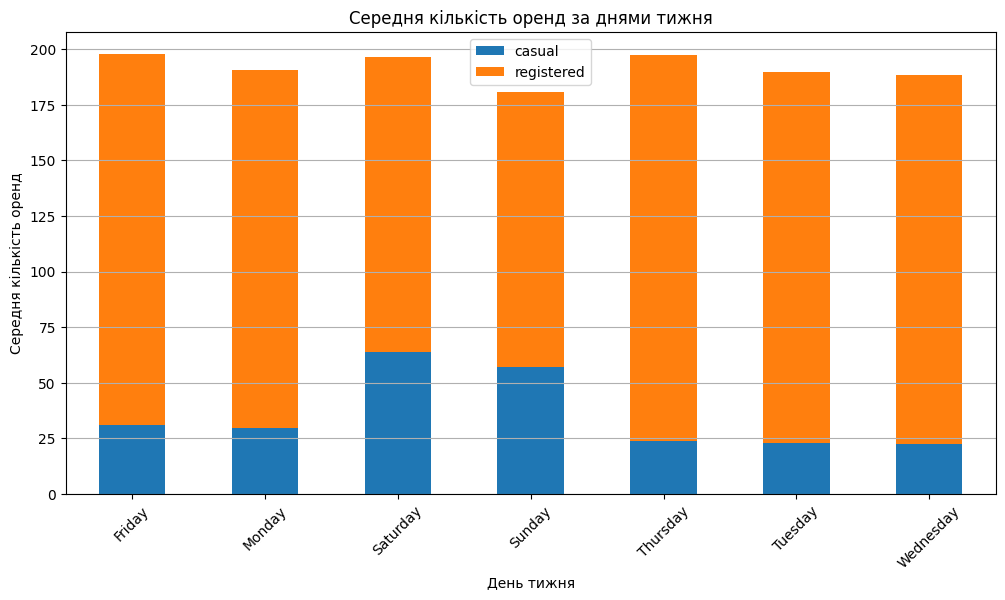

In [43]:
# побудова графіка
ax = avg_users_by_weekday.plot(
    kind='bar',
    stacked = True,
    figsize=(12,6)
)

plt.title('Середня кількість оренд за днями тижня')
plt.xlabel('День тижня')
plt.ylabel('Середня кількість оренд')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

**Відповідь:** 1.Найбільше оренд від зареєстрованих користувачів (registered) припадає на вівторок, середу,четвер,п’ятницю.
У вихідні кількість таких оренд зазвичай знижується.
2.Використання велосипедів як транспорту зареєстрованими користувачами найчастіше: їздять на роботу або навчання, мають стабільні маршрути.
Тому в будні попит значно вищий.Менша потреба у поїздках у вихідні: менше робочих поїздок, люди рідше користуються транспортом зранку.
Через це кількість оренд серед registered падає.Інша поведінка casual-користувачів - орендують велосипеди для прогулянок, використовують їх у вихідні,залежать від хорошої погоди та дозвілля.
Тому у вихідні: casual часто зростає,а registered зменшується.